In [2]:
import pandas
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_predict, cross_val_score
from sklearn.impute import SimpleImputer
from matplotlib.colors import LogNorm
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.compose import ColumnTransformer
from sklearn.naive_bayes import CategoricalNB
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix,roc_curve, auc, precision_score, recall_score, f1_score, precision_recall_fscore_support, ConfusionMatrixDisplay

In [3]:
BLACK = '\033[30m'
RED = '\033[31m'
GREEN = '\033[32m'
YELLOW = '\033[33m' # orange on some systems
BLUE = '\033[34m'
MAGENTA = '\033[35m'
CYAN = '\033[36m'
LIGHT_GRAY = '\033[37m'
DARK_GRAY = '\033[90m'
BRIGHT_RED = '\033[91m'
BRIGHT_GREEN = '\033[92m'
BRIGHT_YELLOW = '\033[93m'
BRIGHT_BLUE = '\033[94m'
BRIGHT_MAGENTA = '\033[95m'
BRIGHT_CYAN = '\033[96m'
RESET = '\033[0m' # called to return to standard terminal text color

def colored_text(color, txt):
    return color + str(txt) + RESET

In [4]:
datasets_path = "data"
years = [2019,2020, 2021, 2022, 2023, 2024]

df_vehicules = []

for year in years:
    df_vehicules_year = pandas.read_csv(os.path.join(datasets_path, str(year), f"vehicules-{year}.csv"), encoding="utf-8", sep = ";")
    df_vehicules.append(df_vehicules_year)

df_vehicules = pandas.concat(df_vehicules)
df_vehicules

,Num_Acc,id_vehicule,num_veh,senc,catv,obs,obsm,choc,manv,motor,occutc
0,201900000001,138 306 524,B01,2,7,0,2,5,23,1,NaN
1,201900000001,138 306 525,A01,2,17,1,0,3,11,1,NaN
2,201900000002,138 306 523,A01,1,7,4,0,1,0,1,NaN
3,201900000003,138 306 520,A01,1,7,0,2,1,2,1,NaN
4,201900000003,138 306 521,B01,1,7,1,0,4,2,1,NaN
...,...,...,...,...,...,...,...,...,...,...,...
92673,202400054401,155 686 119,Y01,1,60,1,2,7,0,5,NaN
92674,202400054401,155 686 120,A01,1,33,1,2,1,1,1,NaN
92675,202400054402,155 686 118,A01,1,10,0,2,1,2,1,NaN
92676,202400054402,155 686 121,B01,1,7,0,2,4,2,1,NaN


In [5]:
df_vehicules["id_vehicule"] = (
    df_vehicules["id_vehicule"]
    .astype(str)
    .str.replace(r"\D", "", regex=True)  # keep only digits
    .astype("int64")
)

In [6]:
df_vehicules.replace(-1, pandas.NA, inplace=True)

for col in df_vehicules.columns:
    prop = df_vehicules[col].isna().sum() / len(df_vehicules)
    print(f"For {colored_text(MAGENTA, col)} proportion missing: {prop * 100:.2f}%")

For Num_Acc proportion missing: 0.00%
For id_vehicule proportion missing: 0.00%
For num_veh proportion missing: 0.00%
For senc proportion missing: 0.26%
For catv proportion missing: 0.00%
For obs proportion missing: 0.04%
For obsm proportion missing: 0.05%
For choc proportion missing: 0.05%
For manv proportion missing: 0.04%
For motor proportion missing: 0.22%
For occutc proportion missing: 99.13%


In [7]:
# First we are dropping features that we are not going to use: num_veh as we will use id_vehicule instead
df_vehicules.drop(columns = ['num_veh', 'occutc'], inplace = True)

In [8]:
# Removing rows with missing values

imputer_obs = SimpleImputer(strategy="most_frequent")
cat_small_na = df_vehicules.columns[(df_vehicules.isna().sum()>0) & (df_vehicules.isna().sum() < 5000)]
print(cat_small_na)
df_vehicules[cat_small_na]= df_vehicules[cat_small_na].replace({pandas.NA: np.nan})
df_vehicules[cat_small_na] = imputer_obs.fit_transform(df_vehicules[cat_small_na])


Index(['senc', 'catv', 'obs', 'obsm', 'choc', 'manv', 'motor'], dtype='str')


In [9]:
# And converting to int
cols_small_int = ['catv', 'obs', 'obsm', 'choc', 'manv', 'motor',"senc"]
df_vehicules[cols_small_int] = df_vehicules[cols_small_int].astype("int64")

In [10]:
categorical_features = cols_small_int[:]
numerical_features = []
features = categorical_features + numerical_features

In [11]:
# We need to load usagers, because it conatains our target column
df_usagers = pandas.read_csv("df_usagers_clean.csv")

df_vehicules_with_target = df_usagers[['Num_Acc', 'id_vehicule', 'grav_bin']].merge(
    df_vehicules,
    on=['Num_Acc', 'id_vehicule'],
    how='left'
)

target = "grav_bin"

In [12]:
df_vehicules_with_target.isna().sum()

Num_Acc        0
id_vehicule    0
grav_bin       0
senc           0
catv           0
obs            0
obsm           0
choc           0
manv           0
motor          0
dtype: int64

In [13]:
df_vehicules_with_target = df_vehicules_with_target.dropna()

In [14]:
df_vehicules_analyse = df_vehicules_with_target.copy() 

mapping = {
    0: "Indéterminable",
    1: "Bicyclette",
    2: "Cyclomoteur <50cm3",
    3: "Voiturette (Quadricycle à moteur carrossé)",
    4: "Référence inutilisée depuis 2006 (scooter immatriculé)",
    5: "Référence inutilisée depuis 2006 (motocyclette)",
    6: "Référence inutilisée depuis 2006 (side-car)",
    7: "VL seul",
    8: "Référence inutilisée depuis 2006 (VL + caravane)",
    9: "Référence inutilisée depuis 2006 (VL + remorque)",
    10: "VU seul 1,5T <= PTAC <= 3,5T avec ou sans remorque",
    11: "Référence inutilisée depuis 2006 (VU (10) + caravane)",
    12: "Référence inutilisée depuis 2006 (VU (10) + remorque)",
    13: "PL seul 3,5T < PTAC <= 7,5T",
    14: "PL seul > 7,5T",
    15: "PL > 3,5T + remorque",
    16: "Tracteur routier seul",
    17: "Tracteur routier + semi-remorque",
    18: "Référence inutilisée depuis 2006 (transport en commun)",
    19: "Référence inutilisée depuis 2006 (tramway)",
    20: "Engin spécial",
    21: "Tracteur agricole",
    30: "Scooter < 50 cm3",
    31: "Motocyclette > 50 cm3 et <= 125 cm3",
    32: "Scooter > 50 cm3 et <= 125 cm3",
    33: "Motocyclette > 125 cm3",
    34: "Scooter > 125 cm3",
    35: "Quad léger <= 50 cm3 (Quadricycle à moteur non carrossé)",
    36: "Quad lourd > 50 cm3 (Quadricycle à moteur non carrossé)",
    37: "Autobus",
    38: "Autocar",
    39: "Train",
    40: "Tramway",
    41: "3RM <= 50 cm3",
    42: "3RM > 50 cm3 <= 125 cm3",
    43: "3RM > 125 cm3",
    50: "EDP à moteur",
    60: "EDP sans moteur",
    80: "VAE",
    99: "Autre véhicule"
}

df_vehicules_analyse["catv"] = df_vehicules_analyse["catv"].replace(mapping)

mapping = {
    0: "Sans objet",
    1: "Véhicule en stationnement",
    2: "Arbre",
    3: "Glissière métallique",
    4: "Glissière béton",
    5: "Autre glissière",
    6: "Bâtiment, mur, pile de pont",
    7: "Support de signalisation verticale ou poste d’appel d’urgence",
    8: "Poteau",
    9: "Mobilier urbain",
    10: "Parapet",
    11: "Ilot, refuge, borne haute",
    12: "Bordure de trottoir",
    13: "Fossé, talus, paroi rocheuse",
    14: "Autre obstacle fixe sur chaussée",
    15: "Autre obstacle fixe sur trottoir ou accotement",
    16: "Sortie de chaussée sans obstacle",
    17: "Buse – tête d’aqueduc"
}

df_vehicules_analyse["obs"]= df_vehicules_analyse["obs"].replace(mapping)

mapping = {
    0: "Aucun",
    1: "Piéton",
    2: "Véhicule",
    4: "Véhicule sur rail",
    5: "Animal domestique",
    6: "Animal sauvage",
    9: "Autre"
}

df_vehicules_analyse["obsm"]= df_vehicules_analyse["obsm"].replace(mapping)

mapping = {
    0: "Aucun",
    1: "Avant",
    2: "Avant droit",
    3: "Avant gauche",
    4: "Arrière",
    5: "Arrière droit",
    6: "Arrière gauche",
    7: "Côté droit",
    8: "Côté gauche",
    9: "Chocs multiples (tonneaux)"
}

df_vehicules_analyse["choc"]= df_vehicules_analyse["choc"].replace(mapping)

mapping = {
    0: "Inconnue",
    1: "Sans changement de direction",
    2: "Même sens, même file",
    3: "Entre 2 files",
    4: "En marche arrière",
    5: "A contresens",
    6: "En franchissant le terre-plein central",
    7: "Dans le couloir bus, dans le même sens",
    8: "Dans le couloir bus, dans le sens inverse",
    9: "En s’insérant",
    10: "En faisant demi-tour sur la chaussée",
    11: "A gauche (changeant de file)",
    12: "A droite (changeant de file)",
    13: "A gauche (déporté)",
    14: "A droite (déporté)",
    15: "A gauche (tournant)",
    16: "A droite (tournant)",
    17: "A gauche (dépassant)",
    18: "A droite (dépassant)",
    19: "Traversant la chaussée",
    20: "Manœuvre de stationnement",
    21: "Manœuvre d’évitement",
    22: "Ouverture de porte",
    23: "Arrêté (hors stationnement)",
    24: "En stationnement (avec occupants)",
    25: "Circulant sur trottoir",
    26: "Autres manœuvres"
}

df_vehicules_analyse["manv"]= df_vehicules_analyse["manv"].replace(mapping)

mapping = {
    0: "Inconnue",
    1: "Hydrocarbures",
    2: "Hybride électrique",
    3: "Electrique",
    4: "Hydrogène",
    5: "Humaine",
    6: "Autre"
}

df_vehicules_analyse["motor"]= df_vehicules_analyse["motor"].replace(mapping)

mapping = {
    0 : "Inconnu" ,  
    1 : "PK ou PR ou numéro d’adresse postale croissant"  ,
    2 : "PK ou PR ou numéro d’adresse postale décroissant" , 
    3 : "Absence de repère"  
}
df_vehicules_analyse["senc"]= df_vehicules_analyse["senc"].replace(mapping)

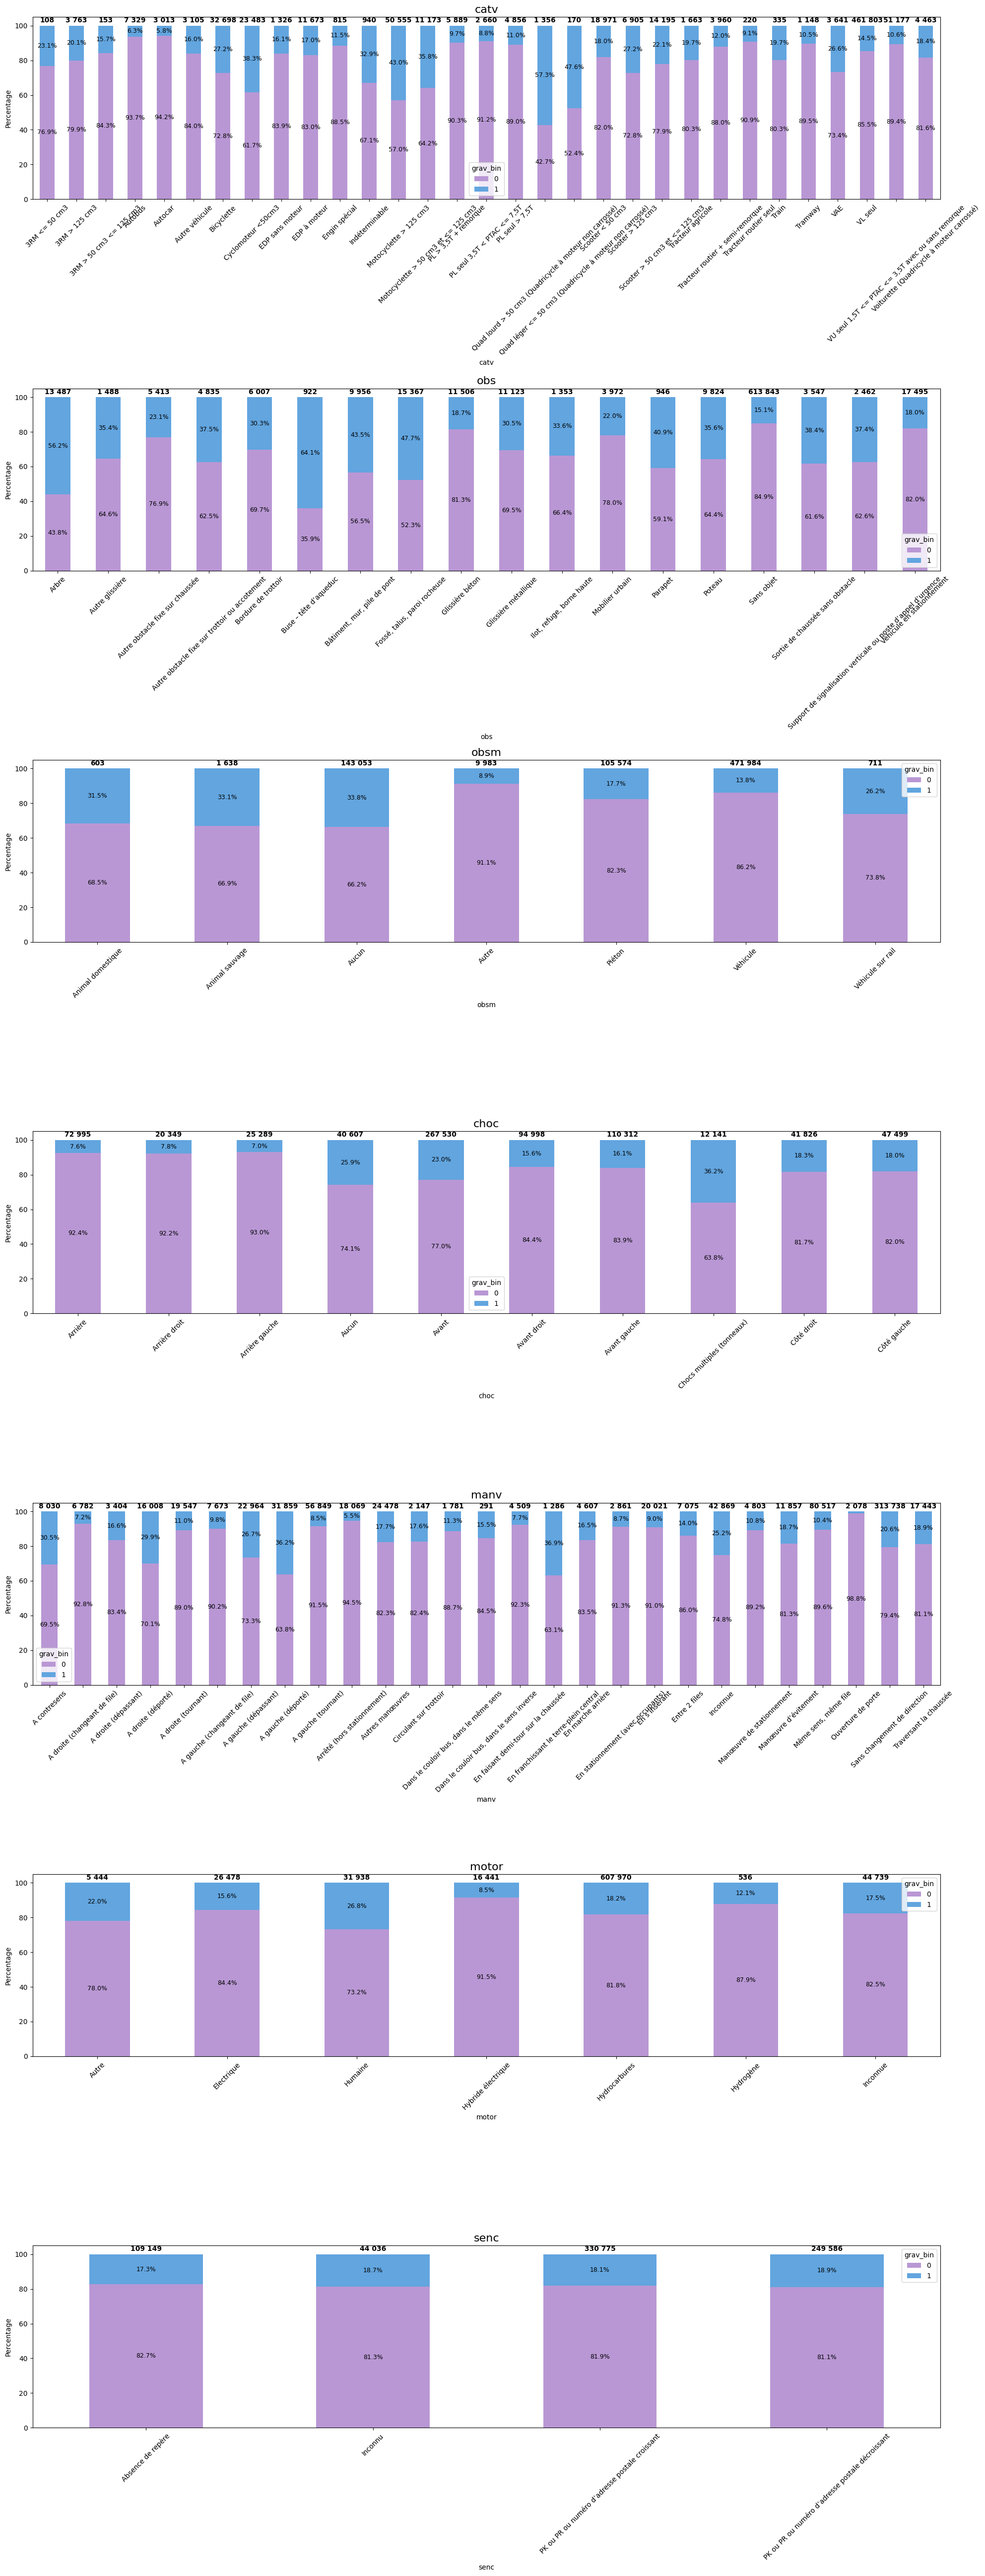

In [15]:
fig, ax = plt.subplots(len(categorical_features), 1, figsize=(20, 6*len(categorical_features) + 10))

for i, feature in enumerate(categorical_features):
    ct = pandas.crosstab(
        df_vehicules_analyse[feature],
        df_vehicules_analyse[target],
        normalize="index"
    ) * 100

    counts = df_vehicules_analyse[feature].value_counts().sort_index()

    # Plot
    ct.plot(kind="bar", stacked=True, ax=ax[i], color=["#B997D4", "#62A5DF"])

    # Add % labels inside bars
    for j, category in enumerate(ct.index):
        cumulative = 0
        for k, col in enumerate(ct.columns):
            value = ct.loc[category, col]
            if value > 3:  # avoid clutter for tiny values
                ax[i].text(
                    j,
                    cumulative + value / 2,
                    f"{value:.1f}%",
                    ha="center",
                    va="center",
                    fontsize=9,
                    color="black"
                )
            cumulative += value

    # Add total count above bars
    for j, category in enumerate(ct.index):
        ax[i].text(
            j,
            101,  # slightly above 100%
            f"{counts[category]:,}".replace(",", " "),
            ha="center",
            va="bottom",
            fontsize=10,
            fontweight="bold"
        )

    ax[i].set_title(feature, fontsize=16)
    ax[i].tick_params(axis='x', rotation=45)
    ax[i].set_ylabel("Percentage")

plt.tight_layout()

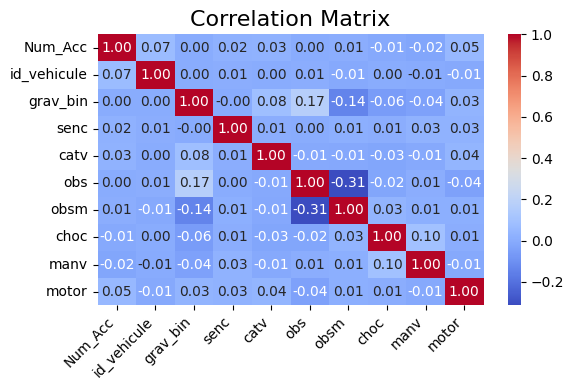

In [16]:
plt.figure(figsize=(6, 4))

sns.heatmap(
    df_vehicules_with_target.corr(),
    cmap="coolwarm",
    annot=True,
    fmt=".2f",
    annot_kws={"size": 10}
)

plt.title("Correlation Matrix", fontsize=16)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

In [17]:
X = df_vehicules_with_target[categorical_features + numerical_features]
y = df_vehicules_with_target[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)


In [18]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(),
    "Gradient Boosting": GradientBoostingClassifier()
}

pipelines = {}
for name, model in models.items():
    pipelines[name] = Pipeline([
        ("preprocessing", preprocessor),
        ("model", model)
    ])

for name, pipe in pipelines.items():
    y_pred = cross_val_predict(pipe, X_train, y_train, cv=5) # un label prédit pour chaque exemple de X_train
    
    precision = precision_score(y_train,y_pred)
    recall = recall_score(y_train, y_pred)
    f1 = f1_score(y_train,y_pred)
    accuracy = accuracy_score(y_train, y_pred)

    print("\n", name)
    print("Precision:", precision)
    print("Recall:", recall)
    print("F1:", f1)
    print("Accuracy:", accuracy)
    
    print(classification_report(y_train, y_pred))




 Logistic Regression
Precision: 0.5711451340894812
Recall: 0.1609647446949293
F1: 0.2511487233176293
Accuracy: 0.8244824789208569
              precision    recall  f1-score   support

           0       0.84      0.97      0.90    479533
           1       0.57      0.16      0.25    107303

    accuracy                           0.82    586836
   macro avg       0.70      0.57      0.58    586836
weighted avg       0.79      0.82      0.78    586836


 Decision Tree
Precision: 0.5199452734191287
Recall: 0.2266665424079476
F1: 0.31570407772535225
Accuracy: 0.8203297002910523
              precision    recall  f1-score   support

           0       0.85      0.95      0.90    479533
           1       0.52      0.23      0.32    107303

    accuracy                           0.82    586836
   macro avg       0.68      0.59      0.61    586836
weighted avg       0.79      0.82      0.79    586836


 Gradient Boosting
Precision: 0.6360587671670392
Recall: 0.11135755757061779
F1: 0.18953

In [19]:
X_tr, X_val, y_tr, y_val = train_test_split(X_train, y_train, test_size = .2)
for name, pipe in pipelines.items():
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_val) # un label prédit pour chaque exemple de X_train
    
    precision, recall, f1, _ = precision_recall_fscore_support(y_val, y_pred, average="binary")
    print("\n", name)
    print("Precision:", precision)
    print("Recall:", recall)
    print("F1:", f1)
    print("Accuracy:", accuracy)
    
    print(classification_report(y_val, y_pred))


 Logistic Regression
Precision: 0.5623571661769508
Recall: 0.15952766844176894
F1: 0.24854803217777136
Accuracy: 0.8258610582854494
              precision    recall  f1-score   support

           0       0.84      0.97      0.90     95773
           1       0.56      0.16      0.25     21595

    accuracy                           0.82    117368
   macro avg       0.70      0.57      0.57    117368
weighted avg       0.79      0.82      0.78    117368


 Decision Tree
Precision: 0.6972416085078099
Recall: 0.29145635563787914
F1: 0.41107700346156356
Accuracy: 0.8258610582854494
              precision    recall  f1-score   support

           0       0.86      0.97      0.91     95773
           1       0.70      0.29      0.41     21595

    accuracy                           0.85    117368
   macro avg       0.78      0.63      0.66    117368
weighted avg       0.83      0.85      0.82    117368


 Gradient Boosting
Precision: 0.6288910505836576
Recall: 0.1197499421162306
F1: 0.201

AUC of Logistic Regression: 0.762
AUC of Decision Tree: 0.734
AUC of Gradient Boosting: 0.767


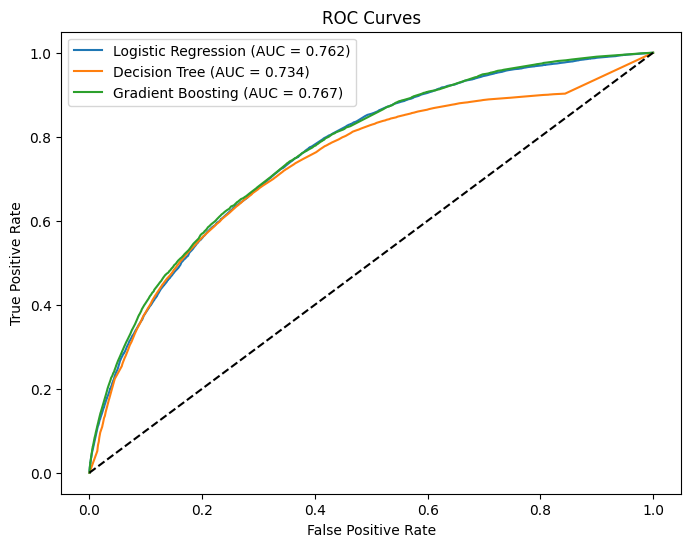

In [20]:
plt.figure(figsize=(8,6))
lst_auc = []

for name, pipe in pipelines.items(): 
    if hasattr(pipe["model"], "predict_proba"):
        y_score = pipe.predict_proba(X_test)[:,1]
    elif hasattr(pipe["model"], "decision_function"):
        y_score = pipe.decision_function(X_test)
    else:
        # fallback: just use predictions (not ideal for ROC, but works)
        y_score = model.predict(X_test)
        print(f"Warning: {name} does not have predict_proba or decision_function, using predict()")

    fpr, tpr, _ = roc_curve(y_test, y_score)
    auc_score = auc(fpr, tpr)
    lst_auc.append((name, auc_score))

    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc_score:.3f})")
    print(f"AUC of {name}: {auc_score:.3f}")

plt.plot([0,1],[0,1], "k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves")
plt.legend()
plt.show()

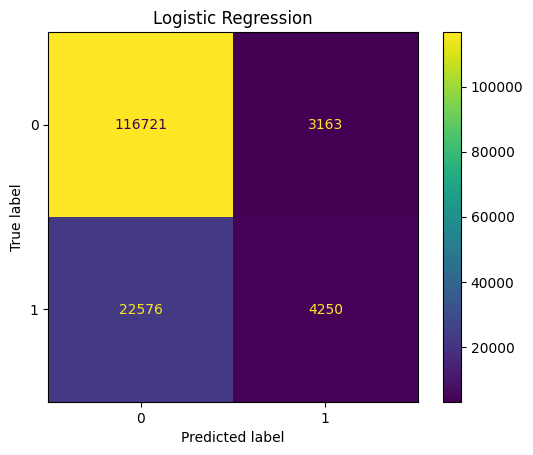

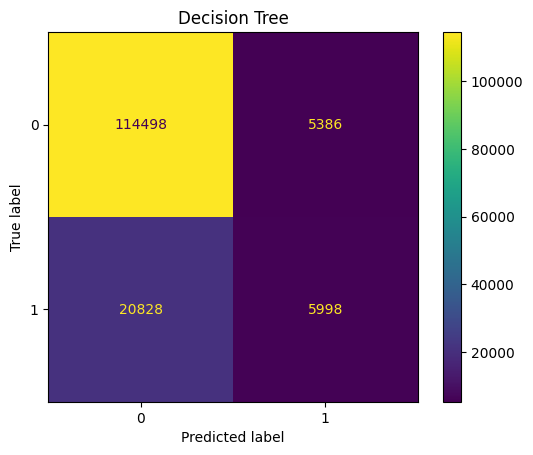

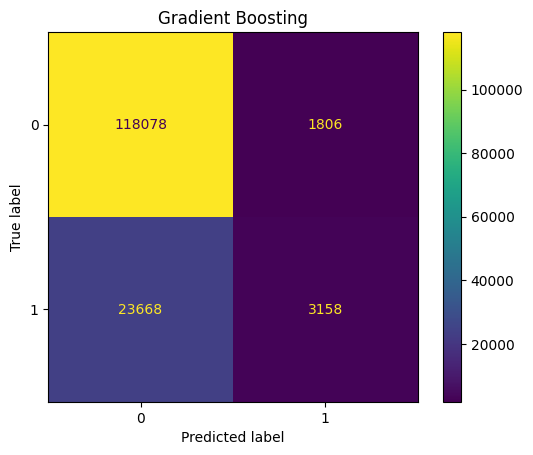

In [21]:
for name, model in pipelines.items():
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot()
    plt.title(name)
    plt.show()

In [22]:
# Finally we are going to save the dataset cleaned
df_vehicules.to_csv("df_vehicules_clean.csv", index=False)

In [23]:
df_vehicules_with_target = df_vehicules_with_target.dropna()